In [23]:
import pandas as pd
df=pd.read_csv(r"C:\Users\firdo\OneDrive\Kaggle Datasets\Reviews.csv")


In [24]:
df.shape

(568454, 10)

In [25]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [26]:
# Take a random sample of 500 rows
sample_df = df.sample(n=300, random_state=42)

# Reset index for clean handling
sample_df = sample_df.reset_index(drop=True)

print(sample_df.shape)
print(sample_df.head())


(300, 10)
       Id   ProductId          UserId             ProfileName  \
0  165257  B000EVG8J2  A1L01D2BD3RKVO  B. Miller "pet person"   
1  231466  B0000BXJIS  A3U62RE5XZDP0G                   Marty   
2  427828  B008FHUFAU   AOXC0JQQZGGB6         Kenneth Shevlin   
3  433955  B006BXV14E  A3PWPNZVMNX3PA             rareoopdvds   
4   70261  B007I7Z3Z0  A1XNZ7PCE45KK7                  Og8ys1   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     0                       0      5  1268179200   
1                     0                       0      5  1298937600   
2                     0                       2      3  1224028800   
3                     0                       1      2  1335312000   
4                     0                       2      5  1334707200   

                                        Summary  \
0  Crunchy & Good Gluten-Free Sandwich Cookies!   
1                            great kitty treats   
2                        

In [27]:
sample_df=sample_df[['Text','Score']]

In [28]:
sample_df.head()

,Text,Score
0,Having tried a couple of other brands of glute...,5
1,My cat loves these treats. If ever I can't fin...,5
2,A little less than I expected. It tends to ha...,3
3,"First there was Frosted Mini-Wheats, in origin...",2
4,and I want to congratulate the graphic artist ...,5


In [29]:
def label_sentiment(score):
    if score >= 4:
        return "positive"
    elif score <= 2:
        return "negative"
    else:
        return "neutral"




In [30]:
sample_df['sentiment'] = sample_df['Score'].apply(label_sentiment)

In [31]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\firdo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [32]:
import re
from nltk.corpus import stopwords

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stopwords.words('english')]
    return " ".join(words)

sample_df['clean_text'] = sample_df['Text'].apply(clean_text)



In [33]:
sample_df.to_csv("sample_reviews.csv", index=False)


In [77]:
import pandas as pd

df = pd.read_csv(r"C:\Users\firdo\OneDrive\Documents\sample_reviews_annotated.csv")
print(df.head())


  Manual Sentiment                                               Text  Score  \
0         Positive  Having tried a couple of other brands of glute...      5   
1         Positive  My cat loves these treats. If ever I can't fin...      5   
2         Negative  A little less than I expected.  It tends to ha...      3   
3          Neutral  First there was Frosted Mini-Wheats, in origin...      2   
4         Positive  and I want to congratulate the graphic artist ...      5   

  sentiment                                         clean_text  
0  positive  tried couple brands glutenfree sandwich cookie...  
1  positive  cat loves treats ever cant find house pop top ...  
2   neutral  little less expected tends muddy taste expecte...  
3  negative  first frosted miniwheats original size frosted...  
4  positive  want congratulate graphic artist putting entir...  


In [78]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df['clean_text'])


In [80]:
from sklearn.model_selection import train_test_split

# Automatic labels
y_auto = df['sentiment']

# Manual labels
y_manual = df['Manual Sentiment']

X_train_auto, X_test_auto, y_train_auto, y_test_auto = train_test_split(
    X, y_auto, test_size=0.2, random_state=42
)

X_train_manual, X_test_manual, y_train_manual, y_test_manual = train_test_split(
    X, y_manual, test_size=0.2, random_state=42
)


In [89]:
print(df_manual['Manual Sentiment'].isna().sum())  
print(df_manual['clean_text'].isna().sum())         

0
0


In [90]:
print(df['Manual Sentiment'].isna().sum())


101


In [84]:
df_manual = df.dropna(subset=['Manual Sentiment'])

print("Remaining rows after dropping NaN:", len(df_manual))
print(df_manual['Manual Sentiment'].unique())


Remaining rows after dropping NaN: 199
['Positive' 'Negative' 'Neutral']


In [85]:

df_manual.isna().sum()

Manual Sentiment    0
Text                0
Score               0
sentiment           0
clean_text          0
dtype: int64

In [93]:
df_manual = df_manual[df_manual['clean_text'].str.strip() != ""]
print("Remaining rows after dropping empty clean_text:", len(df_manual))


Remaining rows after dropping empty clean_text: 199


In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)
X_manual = vectorizer.fit_transform(df_manual['clean_text'])
y_manual = df_manual['Manual Sentiment']


In [97]:
from sklearn.model_selection import train_test_split

X_train_manual, X_test_manual, y_train_manual, y_test_manual = train_test_split(
    X_manual, y_manual, test_size=0.2, random_state=42
)


In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Logistic Regression
log_auto = LogisticRegression(max_iter=1000).fit(X_train_auto, y_train_auto)
log_manual = LogisticRegression(max_iter=1000).fit(X_train_manual, y_train_manual)


# Naive Bayes
nb_auto = MultinomialNB().fit(X_train_auto, y_train_auto)
nb_manual = MultinomialNB().fit(X_train_manual, y_train_manual)


In [99]:
results = {
    "Logistic Regression (Auto)": accuracy_score(y_test_auto, log_auto.predict(X_test_auto)),
    "Logistic Regression (Manual)": accuracy_score(y_test_manual, log_manual.predict(X_test_manual)),
    "Naive Bayes (Auto)": accuracy_score(y_test_auto, nb_auto.predict(X_test_auto)),
    "Naive Bayes (Manual)": accuracy_score(y_test_manual, nb_manual.predict(X_test_manual)),
}

for model, acc in results.items():
    print(f"{model}: {acc:.2f}")


Logistic Regression (Auto): 0.82
Logistic Regression (Manual): 0.68
Naive Bayes (Auto): 0.82
Naive Bayes (Manual): 0.68


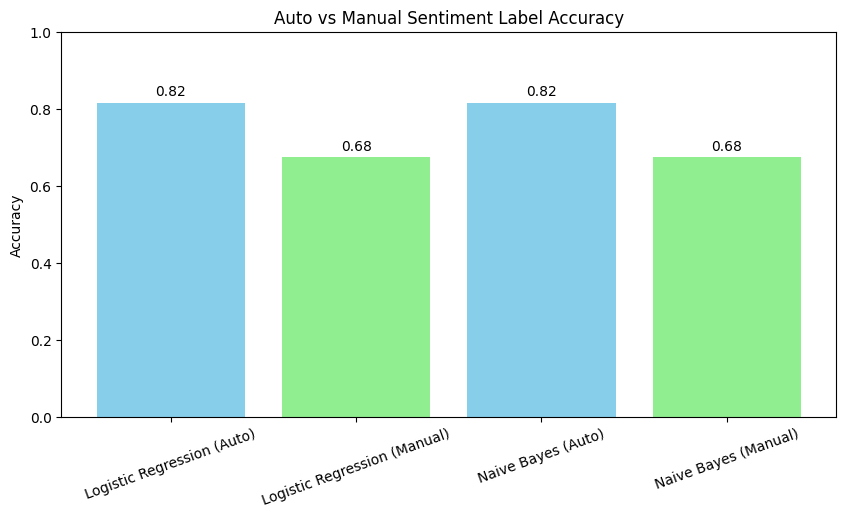

In [103]:
import matplotlib.pyplot as plt

models = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,5))
bars = plt.bar(models, accuracies, color=['skyblue','lightgreen','skyblue','lightgreen'])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Auto vs Manual Sentiment Label Accuracy")

# Add accuracy labels on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{acc:.2f}", ha='center', va='bottom')

plt.xticks(rotation=20)
plt.show()
